In [1]:
# Load the data and clean 

In [25]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.preprocessing import StandardScaler


ModuleNotFoundError: No module named 'torch'

In [4]:
df = pd.read_csv(r"C:\Users\hajdu\Documents\Rowanie\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
print(df['TotalCharges'].apply(type).value_counts())

TotalCharges
<class 'str'>    7043
Name: count, dtype: int64


In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaNs with rounded median
median_charge = round(df['TotalCharges'].median(), 2)
df['TotalCharges'] = df['TotalCharges'].fillna(median_charge)

In [11]:
df_1hot = pd.get_dummies(
    df,
    columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
               'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
    drop_first=True,
    dtype = int
)

In [12]:
X = df_1hot.drop(columns=['customerID', 'Churn_Yes']).values
y = df_1hot['Churn_Yes'].values

In [13]:
df_1hot

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,7590-VHVEG,0,1,29.85,29.85,0,1,0,0,1,...,0,0,0,0,0,1,0,1,0,0
1,5575-GNVDE,0,34,56.95,1889.50,1,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
2,3668-QPYBK,0,2,53.85,108.15,1,0,0,1,0,...,0,0,0,0,0,1,0,0,1,1
3,7795-CFOCW,0,45,42.30,1840.75,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,9237-HQITU,0,2,70.70,151.65,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0,24,84.80,1990.50,1,1,1,1,0,...,1,0,1,1,0,1,0,0,1,0
7039,2234-XADUH,0,72,103.20,7362.90,0,1,1,1,0,...,1,0,1,1,0,1,1,0,0,0
7040,4801-JZAZL,0,11,29.60,346.45,0,1,1,0,1,...,0,0,0,0,0,1,0,1,0,0
7041,8361-LTMKD,1,4,74.40,306.60,1,1,0,1,0,...,0,0,0,0,0,1,0,0,1,1


In [14]:
def plot_correlation(df, figsize=(12, 10), cmap='coolwarm', annot=True):
    """
    Plot a correlation heatmap for all numeric columns in the DataFrame.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        figsize (tuple): Size of the figure
        cmap (str): Color palette ('coolwarm', 'viridis', 'Blues', etc.)
        annot (bool): Whether to show correlation values on the cells
    """
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=['number'])
    
    if numeric_df.empty:
        print("No numeric columns found in the DataFrame.")
        return
    
    # Calculate correlation matrix
    corr_matrix = numeric_df.corr()
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    sns.heatmap(corr_matrix, 
                annot=annot, 
                fmt='.2f', 
                cmap=cmap, 
                linewidths=0.5, 
                cbar_kws={'shrink': 0.8},
                square=True)
    
    plt.title('Correlation Heatmap of All Numeric Variables', fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

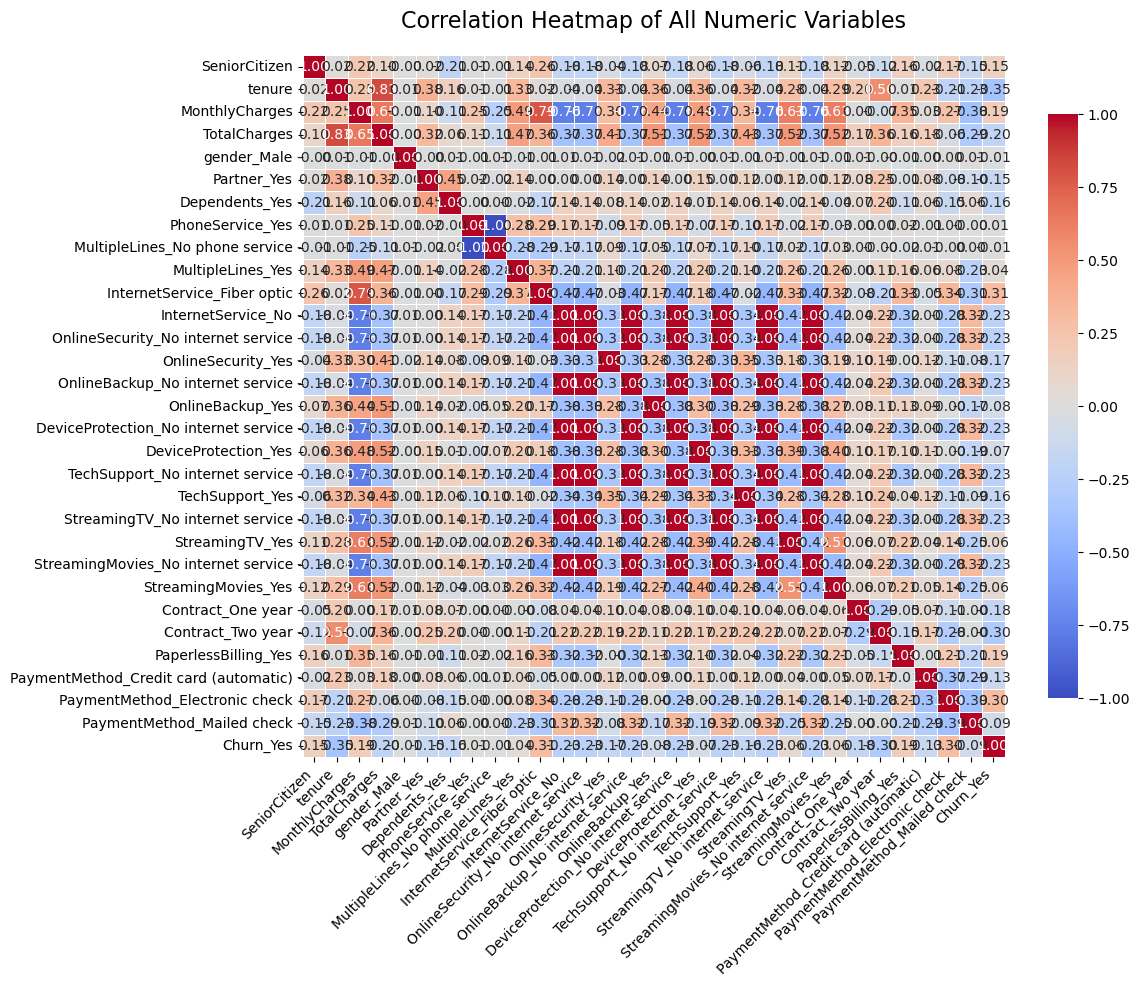

In [15]:
plot_correlation(df_1hot) 

In [16]:
# There is way too many variables, so we want to reduce them
# for that, we will use a random tree model

In [17]:
model_type = tree.DecisionTreeClassifier()
model = model_type.fit(X, y) 

In [18]:

# Use the column names from your original data source
feat_importances = pd.Series(model.feature_importances_, index=df_1hot.drop(columns=['customerID', 'Churn_Yes']).columns)

feat_importances.nlargest(30)

tenure                                   0.216267
TotalCharges                             0.209952
MonthlyCharges                           0.169961
InternetService_Fiber optic              0.108313
gender_Male                              0.026494
PaymentMethod_Electronic check           0.024671
SeniorCitizen                            0.020592
Partner_Yes                              0.020210
DeviceProtection_Yes                     0.018284
Dependents_Yes                           0.018136
PaperlessBilling_Yes                     0.017263
MultipleLines_Yes                        0.016396
OnlineBackup_Yes                         0.015876
TechSupport_Yes                          0.015051
PaymentMethod_Mailed check               0.014376
PaymentMethod_Credit card (automatic)    0.014079
OnlineSecurity_Yes                       0.014031
Contract_One year                        0.012280
StreamingTV_Yes                          0.012070
StreamingMovies_Yes                      0.010181


In [19]:
important_features = feat_importances[feat_importances > 0.01].index.tolist()

In [20]:
X = df_1hot[important_features]

In [21]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1
2,0,2,53.85,108.15,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0
4,0,2,70.70,151.65,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1,1,1,1,0,1,0,1,1,1,1,1,1,0,0,1
7039,0,72,103.20,7362.90,0,1,1,1,1,0,1,1,0,1,1,1,1,1,0,0
7040,0,11,29.60,346.45,0,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,1,0,1,1,0,0,0,0,0,0,0,1,0,0,1


Numerical variables used: ['tenure', 'MonthlyCharges', 'TotalCharges']


Text(0.5, 1.02, 'Scatter Plot Matrix for numerical variables')

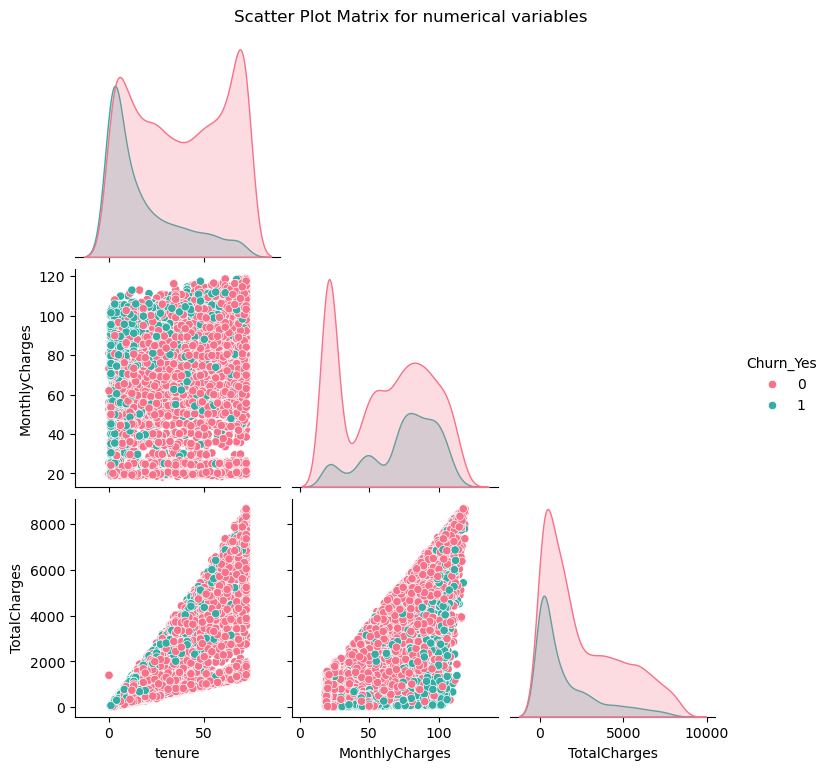

In [24]:
# Scatter plot matrix for numericals 

num_features = [col for col in important_features if df_1hot[col].nunique() > 2]

print(f"Numerical variables used: {num_features}")

plot_data = df_1hot[num_features].copy()
plot_data['Churn_Yes'] = df_1hot['Churn_Yes']

sns.pairplot(
    data=plot_data, 
    hue='Churn_Yes',      
    palette='husl',       
    diag_kind='kde',     
    corner=True           
)

plt.suptitle('Scatter Plot Matrix for numerical variables', y=1.02)